In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

c:\Users\nasta\anaconda3\envs\ssp_metamodel_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [2]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [3]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v5.9.csv") #NOTE: update filename as needed
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
0,0.303285,0.037934,0.617066,0.097521,0.469836,0.216534,0.944742,0.040950,0.701681,0.570068,...,0.323321,0.466898,141.279585,4969.142588,12661.766840,1.095336e+09,-4.115464,0.940284,2518.479115,519262.615092
1,0.377135,0.539486,0.857265,0.025950,0.012477,0.783614,0.586953,0.735174,0.228259,0.358530,...,0.229789,0.188339,111.105432,4653.784493,12705.369862,1.134537e+09,-6.955755,1.087341,1690.944493,66412.565922
2,0.952401,0.228593,0.972167,0.960658,0.159089,0.039879,0.327936,0.331580,0.095386,0.152911,...,0.195396,0.332572,162.202210,5253.589098,13067.486466,1.098871e+09,-4.742205,1.034241,19821.037601,65756.314553
3,0.765244,0.871007,0.325361,0.045184,0.537098,0.040606,0.761664,0.575896,0.146927,0.906716,...,0.664778,0.138639,174.543479,5439.824263,12974.920136,1.040931e+09,-4.583128,0.718387,908.045115,62500.939063
4,0.082978,0.171474,0.720600,0.619098,0.797104,0.821825,0.820461,0.125243,0.682362,0.563160,...,0.417463,0.635064,91.608967,4363.325533,12229.952281,1.130174e+09,-9.966251,1.143989,15529.498669,56867.313635


## EDA

In [4]:
edau = EDAUtils()

In [5]:
target_cols = [col for col in training_df.columns if not(col.startswith("group_"))]
target_cols

['emission_avg_last_five_years',
 'emission_total',
 'production_total',
 'production_cost_total',
 'technical_cost',
 'air_pollution',
 'num_jobs',
 'earning_per_job']

In [6]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha',
 'group_2_frac_agrc_agriculture_production_lost',
 'group_3_frac_agrc',
 'group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture',
 'group_5_nemomod_entc_frac_min_share_production_fp_hydrogen',
 'group_6_nemomod_en',
 'group_7_',
 'group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel',
 'group_9_efficfactor_enfu_industrial_energy_fuel',
 'group_10_scalar_inen_energy_demand',
 'group_11_frac_inen_energy',
 'group_12_frac_ippu_cement_clinker',
 'group_13_ef_ippu_tonne_c',
 'group_14_ef_ippu_tonne_n2o_per_tonne_production',
 'group_15_ef_ippu_tonne_c',
 'group_16_pij_lndu',
 'group_17_frac_lndu_improved_pastures',
 'group_18_lndu_reallocation_factor',
 'group_19_gasrf_lsmm_biogas_anaerobic',
 'group_20_frac_lvst_mm',
 'group_21_frac_lvst_mm',
 'group_22_frac_lvst_mm_chickens',
 'group_23_ef_lvst_entferm',
 'group_24_frac_gnrl_eating_red_meat',
 'group_25_frac_ippu_production_with_co2_capture',
 'group_26_scalar_scoe_heat_energy_de

In [7]:
training_df[target_cols].describe()

,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
count,977.000000,977.000000,977.000000,9.770000e+02,977.000000,977.000000,977.000000,9.770000e+02
mean,136.875756,4961.346320,13277.744433,1.138022e+09,-8.809939,0.947819,10245.016405,6.970685e+04
std,37.467978,485.573265,1130.915496,6.165148e+07,3.182392,0.229302,6679.485915,1.109257e+06
min,41.738601,3699.707313,10507.817224,9.755559e+08,-20.351370,0.243286,-8473.731915,-2.229501e+07
25%,109.023335,4602.470379,12441.793292,1.091542e+09,-10.814151,0.777739,5158.254703,4.960629e+04
50%,135.703024,4944.103606,13236.732927,1.137997e+09,-8.784749,0.957197,10281.892022,7.223075e+04
75%,164.127436,5312.525558,14165.692526,1.183875e+09,-6.432468,1.126454,15313.068435,1.023555e+05
max,238.795901,6277.442847,15965.037220,1.307907e+09,-1.067835,1.538280,26387.461308,2.381724e+07


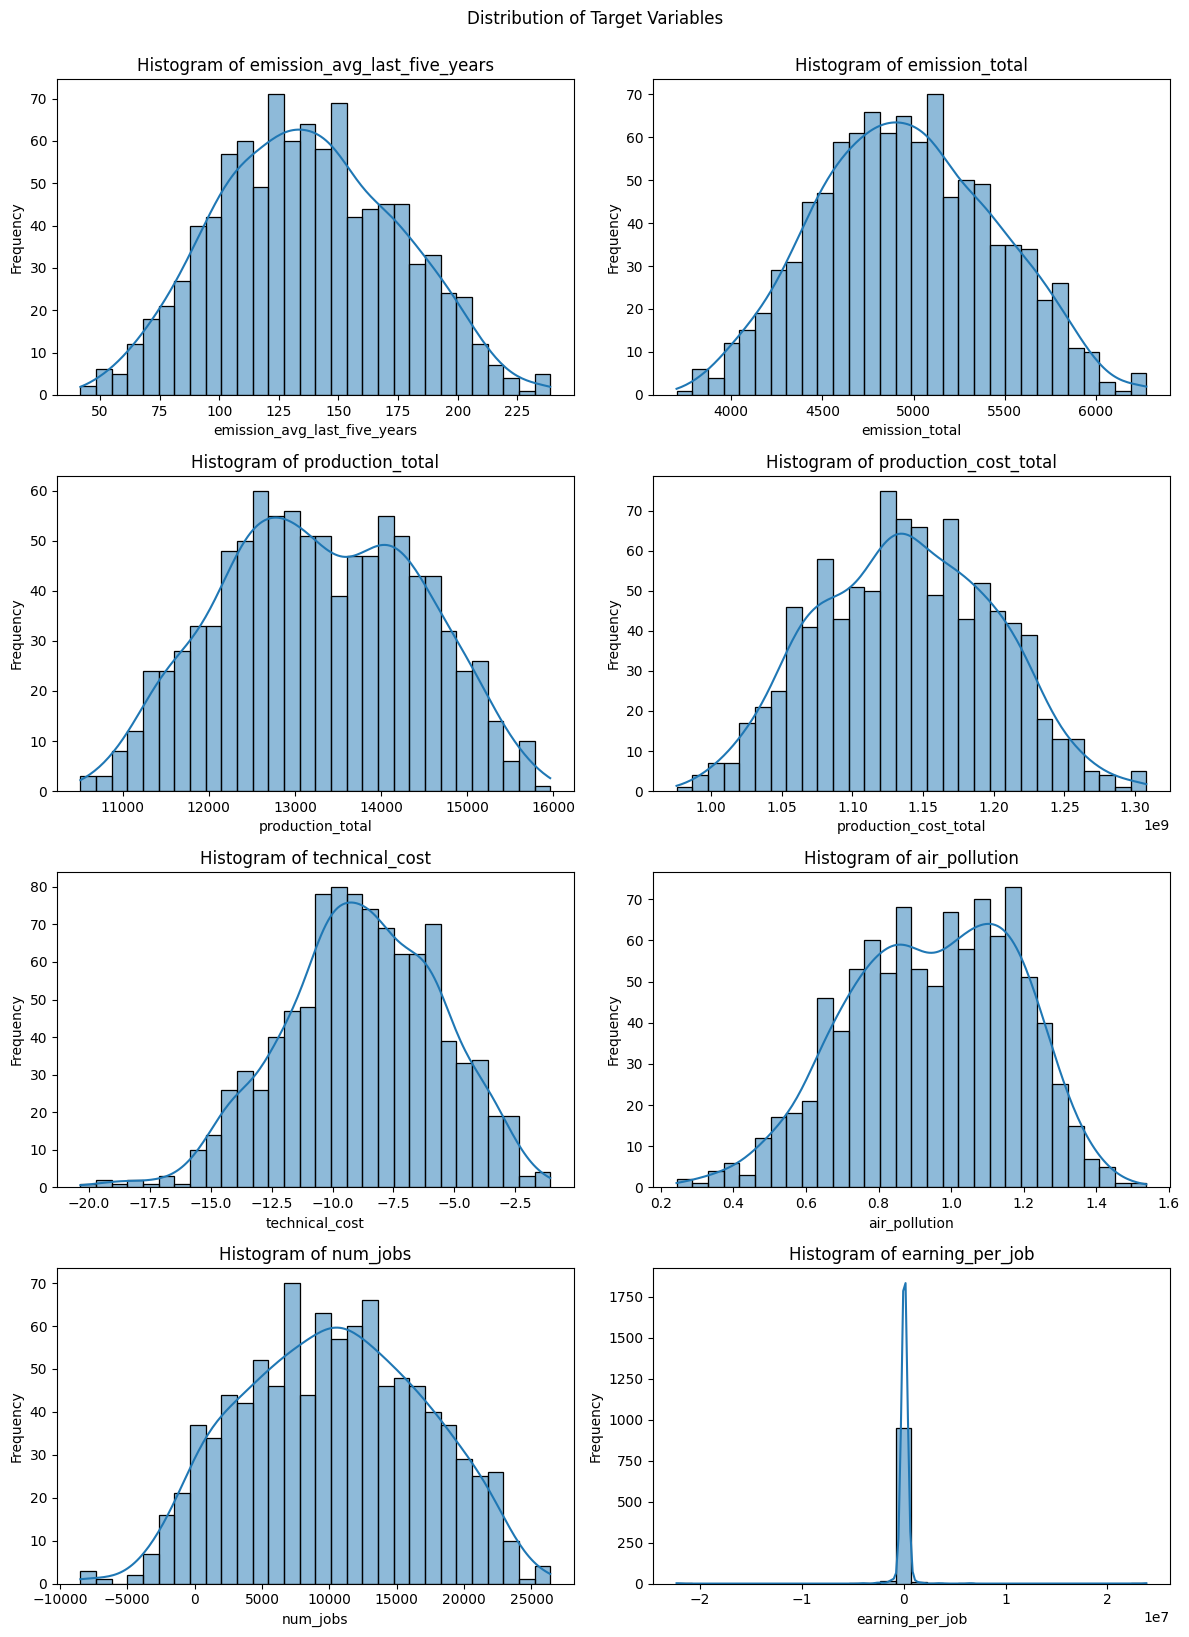

In [8]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")

In [9]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "num_jobs", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "earning_per_job", exclude_cols=target_cols)
	


Pearson correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
group_6_nemomod_en             : 0.6172
group_11_frac_inen_energy      : 0.5522
group_25_frac_ippu_production_with_co2_capture : 0.2604
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2362
group_7_                       : 0.2265
group_46_exports_enfu_pj_fuel  : 0.2203
group_48_gdp_mmm_usd           : 0.1990
group_9_efficfactor_enfu_industrial_energy_fuel : 0.1588
group_35_frac_trns_fuelmix_road_light : 0.1229
group_37_frac_trns_fuelmix     : 0.1201
group_10_scalar_inen_energy_demand : 0.1015


Pearson correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
group_6_nemomod_en             : 0.6399
group_11_frac_inen_energy      : 0.5646
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2412
group_7_                       : 0.2291
group_25_frac

In [ ]:
# Find constant / near-constant cols
# const_cols = edau.find_constant_columns(training_df)
# near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
# print("Constant:", const_cols)
# print("Near-constant:", near_const_cols)

In [10]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)

Outlier percentages: {'technical_cost': 0.61, 'air_pollution': 0.1, 'earning_per_job': 17.2}


## Data Cleaning

In [11]:
dcu = DataCleaningUtils()

In [12]:
training_df.shape

(977, 67)

In [ ]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [ ]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [13]:

training_df_cleaned = dcu.remove_outliers(training_df, method="iqr", factor=1.5)
print("Shape before removing outliers:", training_df.shape)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape before removing outliers: (977, 67)
Shape after removing outliers: (803, 67)


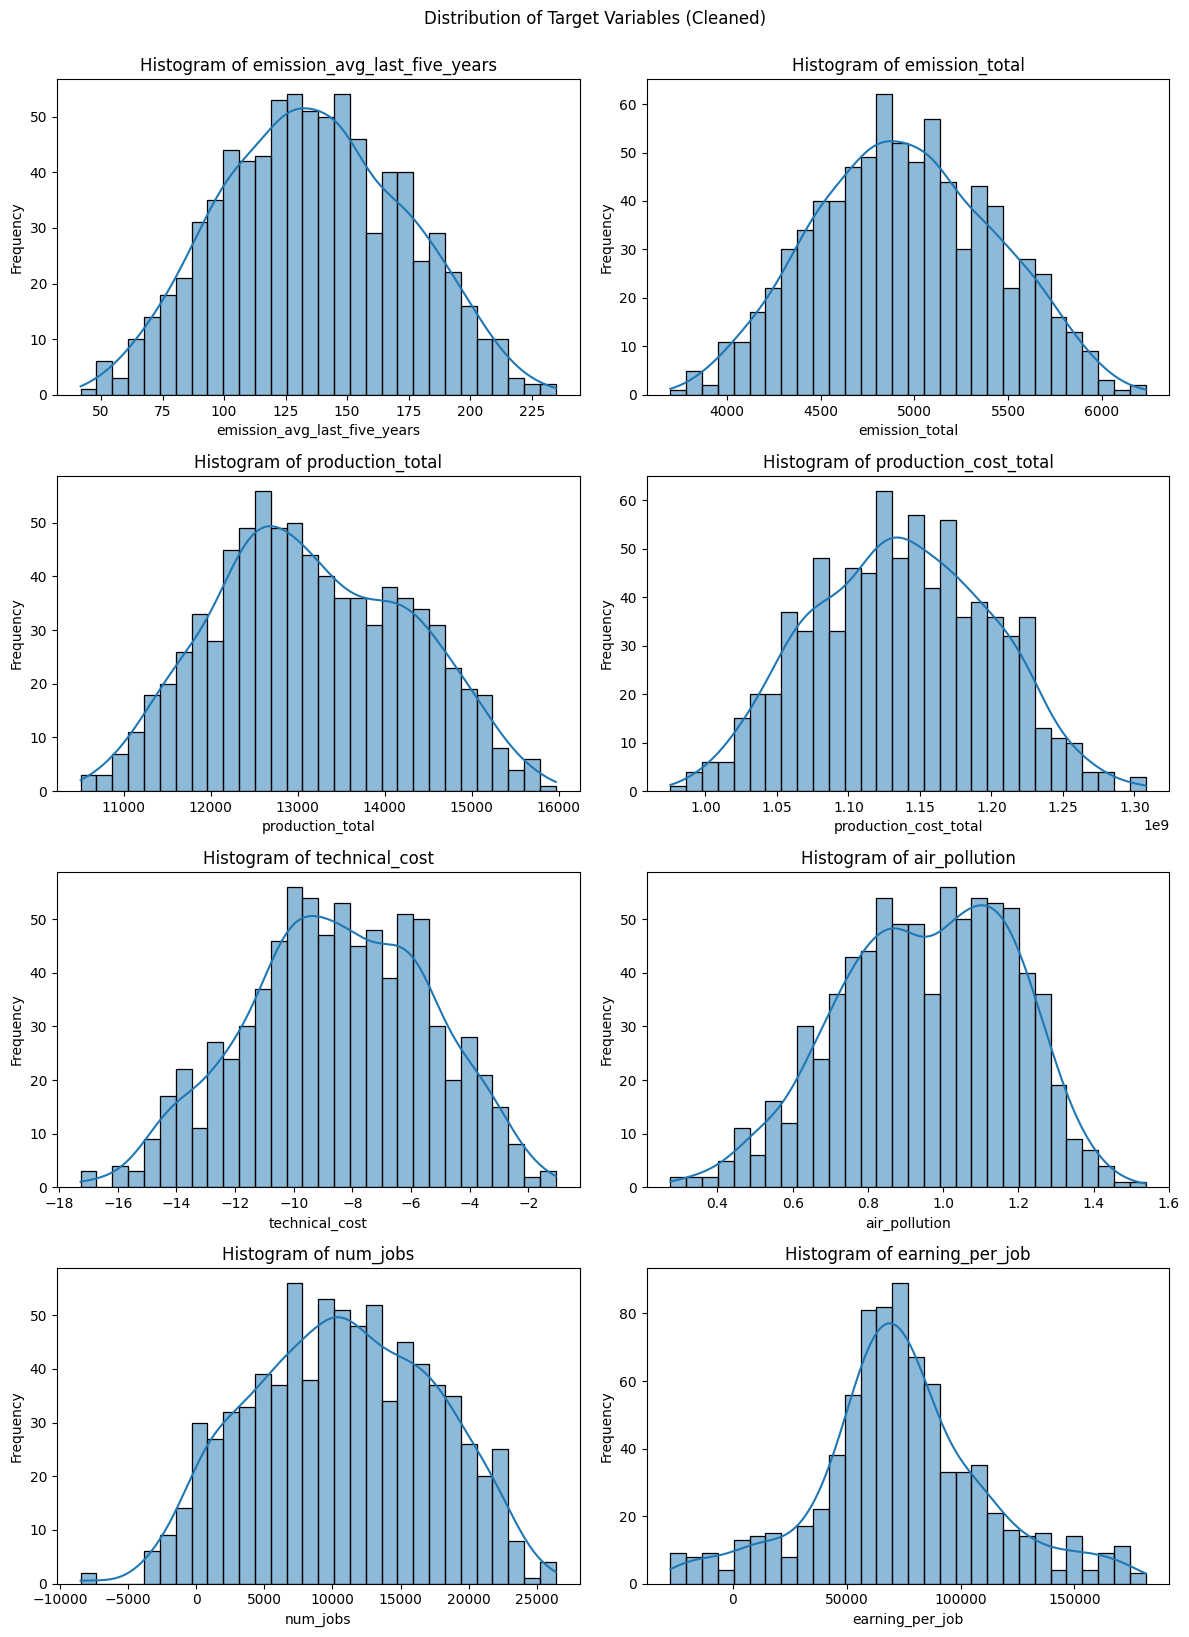

In [14]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [15]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'air_pollution': 0.12}


In [16]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "num_jobs", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "earning_per_job", exclude_cols=target_cols)


Pearson correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------
group_6_nemomod_en             : 0.6172
group_11_frac_inen_energy      : 0.5522
group_25_frac_ippu_production_with_co2_capture : 0.2604
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2362
group_7_                       : 0.2265
group_46_exports_enfu_pj_fuel  : 0.2203
group_48_gdp_mmm_usd           : 0.1990
group_9_efficfactor_enfu_industrial_energy_fuel : 0.1588
group_35_frac_trns_fuelmix_road_light : 0.1229
group_37_frac_trns_fuelmix     : 0.1201
group_10_scalar_inen_energy_demand : 0.1015


Pearson correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------
group_6_nemomod_en             : 0.6399
group_11_frac_inen_energy      : 0.5646
group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture : 0.2412
group_7_                       : 0.2291
group_25_frac

In [17]:
training_df_cleaned[target_cols].describe()

,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
count,803.000000,803.000000,803.000000,8.030000e+02,803.000000,803.000000,803.000000,803.000000
mean,136.004579,4947.429387,13166.754028,1.136707e+09,-8.530387,0.954947,10716.922828,73800.708064
std,36.797619,476.031784,1108.322620,6.173796e+07,3.102775,0.226713,6596.392882,38035.596162
min,41.738601,3699.707313,10507.817224,9.755559e+08,-17.266801,0.275214,-8473.731915,-27422.901896
25%,108.834317,4595.228200,12352.498478,1.089577e+09,-10.603454,0.791481,5641.962861,54804.182184
50%,135.037799,4936.060895,13062.805457,1.136928e+09,-8.496118,0.971406,10610.758476,72230.751416
75%,162.740883,5303.889662,14043.335298,1.181951e+09,-6.160000,1.131785,15824.801455,93040.513465
max,234.812640,6233.079010,15965.037220,1.307907e+09,-1.067835,1.538280,26387.461308,181251.892625


In [ ]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [ ]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

### Individual Training

In [ ]:
# negative_emissions_df = training_df_cleaned[lhs_group_cols + ["total_negative_emissions"]]
# positive_emissions_df = training_df_cleaned[lhs_group_cols + ["total_positive_emissions"]]


In [ ]:
# negative_epp = EmissionsPredictionPipeline(
#     df=negative_emissions_df,
#     target="total_negative_emissions",
#     test_size=0.2,
#     random_state=42,
# )

# negative_epp.run(tune=False, log_transform=False, create_plots=False)

In [ ]:
# positive_epp = EmissionsPredictionPipeline(
#     df=positive_emissions_df,
#     target="total_positive_emissions",
#     test_size=0.2,
#     random_state=42,
# )
# positive_epp.run(tune=False, log_transform=False, create_plots=False)

### Multi Output Training

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB hyperparameters: {'subsample': 0.7, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.7}

=== XGB ===
emission_avg_last_five_years  
  Train → MAE: 1.3707, RMSE: 1.7539, R²: 0.9977, SMAPE: 1.1%
   Test → MAE: 7.5061, RMSE: 9.6333, R²: 0.9297, SMAPE: 5.9%
emission_total                
  Train → MAE: 17.7882, RMSE: 22.2522, R²: 0.9978, SMAPE: 0.4%
   Test → MAE: 105.8387, RMSE: 131.6398, R²: 0.9205, SMAPE: 2.2%
production_total              
  Train → MAE: 25.3919, RMSE: 31.8351, R²: 0.9992, SMAPE: 0.2%
   Test → MAE: 111.1535, RMSE: 142.5054, R²: 0.9826, SMAPE: 0.8%
production_cost_total         
  Train → MAE: 1496019.2342, RMSE: 1915195.3052, R²: 0.9990, SMAPE: 0.1%
   Test → MAE: 7337033.1055, RMSE: 8929560.9285, R²: 0.9795, SMAPE: 0.6%
technical_cost                
  Train → MAE: 0.1704, RMSE: 0.2168, R²: 0.9951, SMAPE: 2.3%
   Test → MAE: 0.74

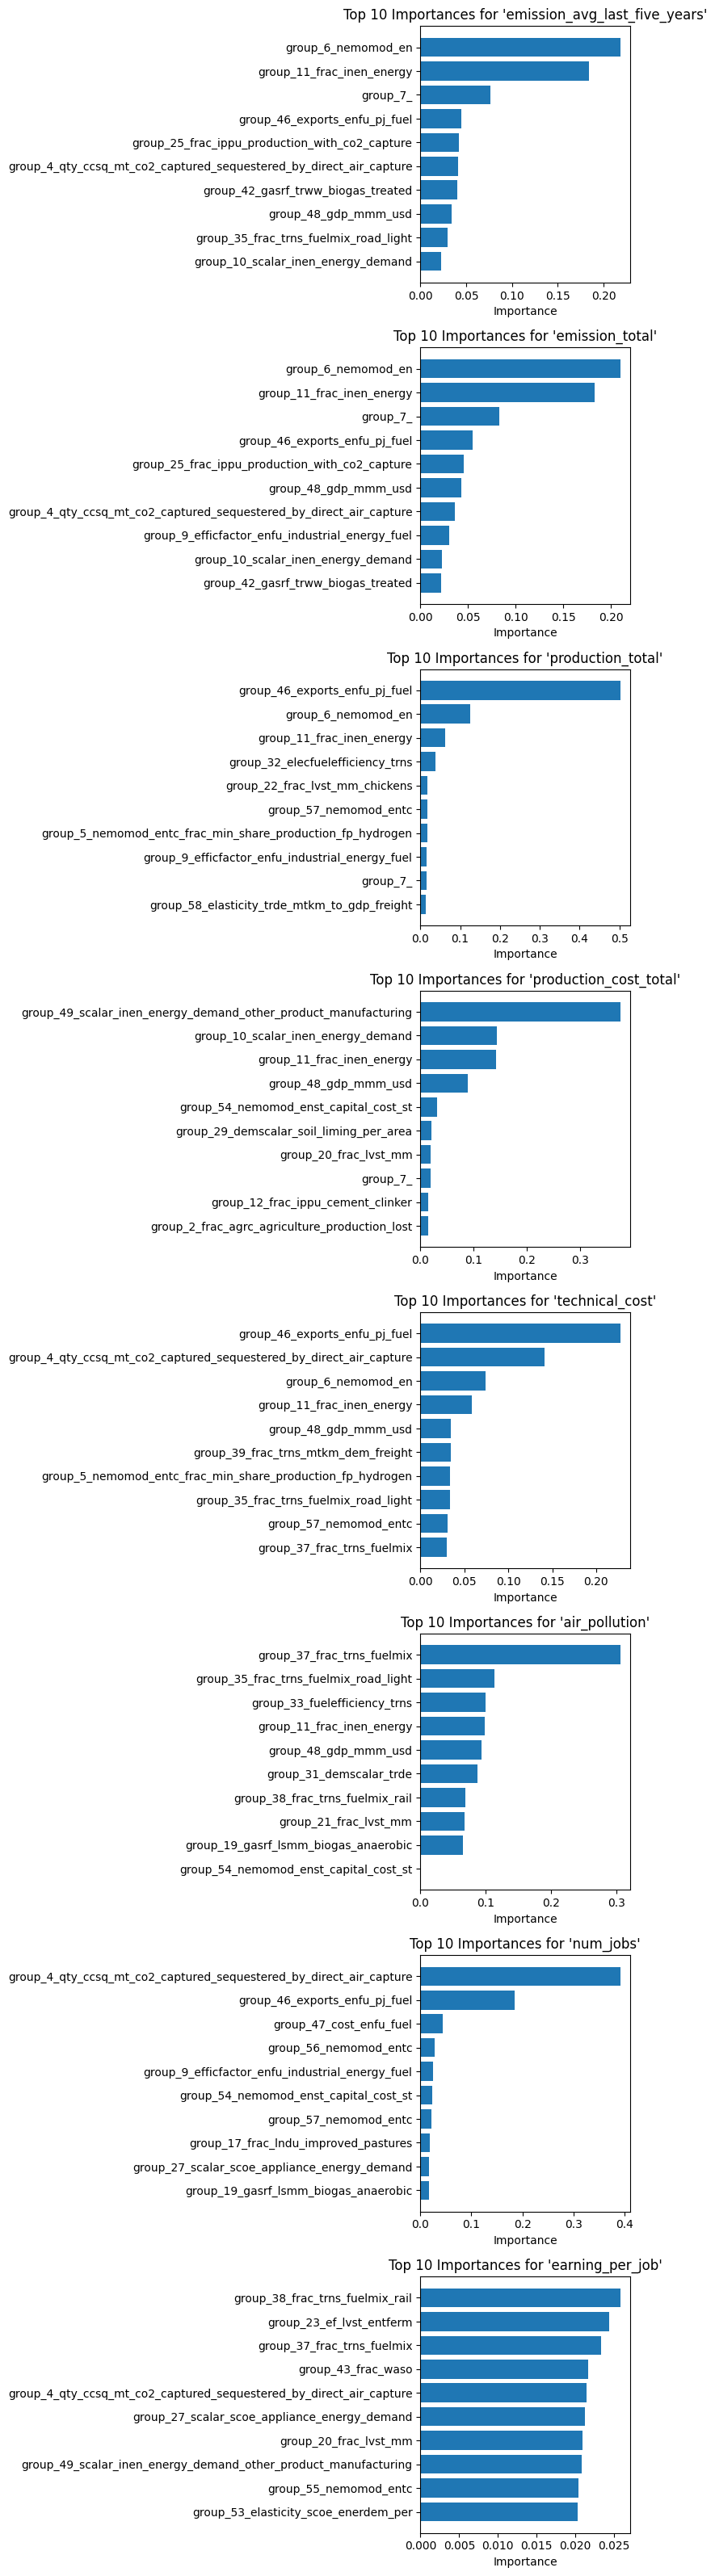

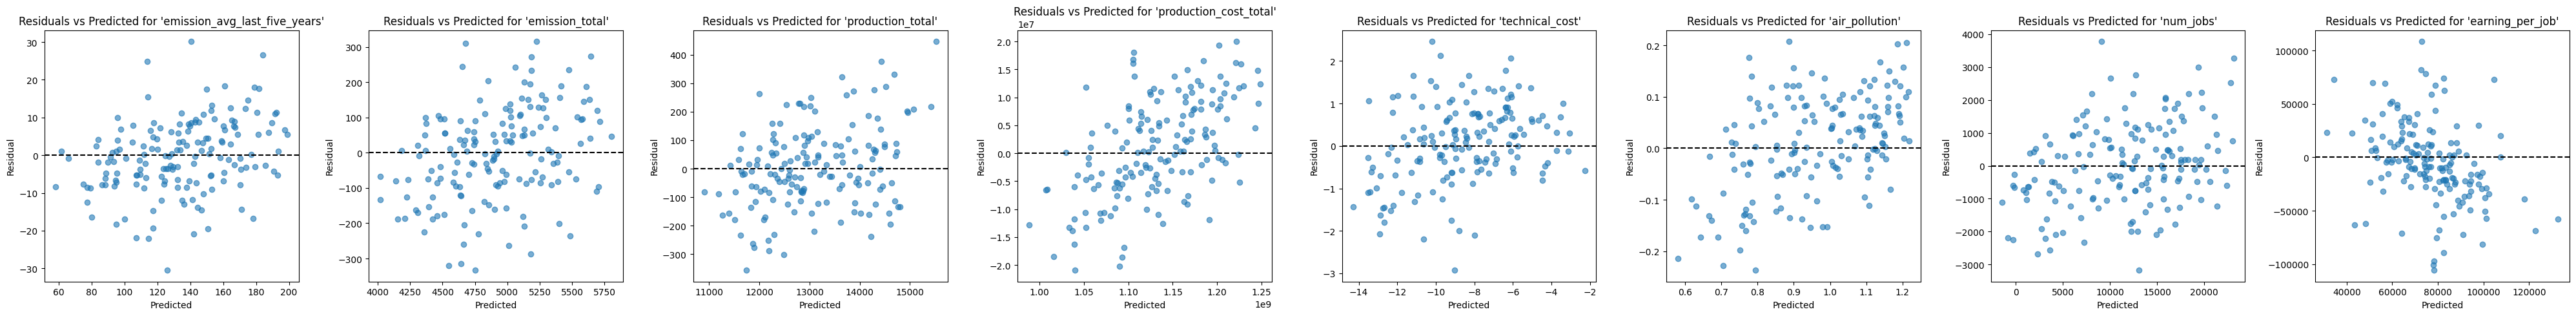

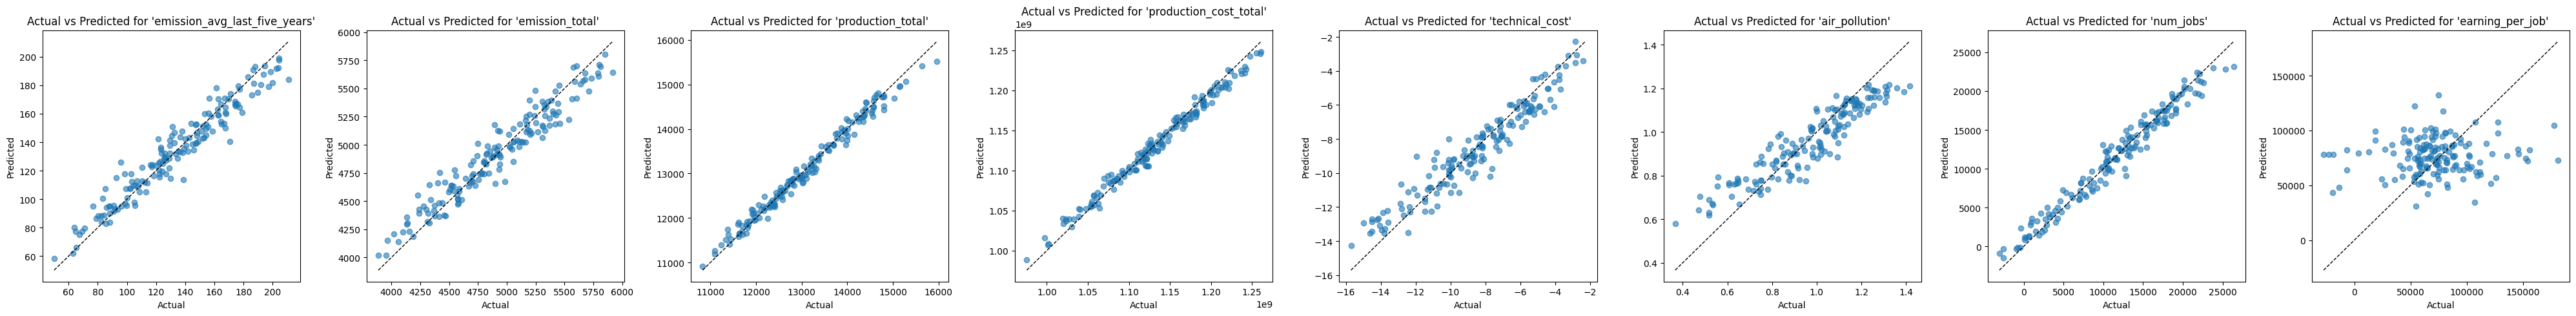

In [18]:
mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=target_cols)
mulp.run(tune=True, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [19]:
training_df_cleaned.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
1,0.377135,0.539486,0.857265,0.025950,0.012477,0.783614,0.586953,0.735174,0.228259,0.358530,...,0.229789,0.188339,111.105432,4653.784493,12705.369862,1.134537e+09,-6.955755,1.087341,1690.944493,66412.565922
2,0.952401,0.228593,0.972167,0.960658,0.159089,0.039879,0.327936,0.331580,0.095386,0.152911,...,0.195396,0.332572,162.202210,5253.589098,13067.486466,1.098871e+09,-4.742205,1.034241,19821.037601,65756.314553
3,0.765244,0.871007,0.325361,0.045184,0.537098,0.040606,0.761664,0.575896,0.146927,0.906716,...,0.664778,0.138639,174.543479,5439.824263,12974.920136,1.040931e+09,-4.583128,0.718387,908.045115,62500.939063
4,0.082978,0.171474,0.720600,0.619098,0.797104,0.821825,0.820461,0.125243,0.682362,0.563160,...,0.417463,0.635064,91.608967,4363.325533,12229.952281,1.130174e+09,-9.966251,1.143989,15529.498669,56867.313635
5,0.147868,0.867401,0.977370,0.794701,0.952113,0.249225,0.388030,0.880942,0.715635,0.107973,...,0.074985,0.651455,136.222646,4936.861748,13549.491773,1.272913e+09,-14.546914,1.256896,18799.460065,171506.933274


In [20]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(target_cols)
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_50_elasticity_ippu,group_51_elasticity_ippu_product_use,group_52_population_gnrl,group_53_elasticity_scoe_enerdem_per,group_54_nemomod_enst_capital_cost_st,group_55_nemomod_entc,group_56_nemomod_entc,group_57_nemomod_entc,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc
1,0.377135,0.539486,0.857265,0.02595,0.012477,0.783614,0.586953,0.735174,0.228259,0.35853,...,0.155687,0.670921,0.492146,0.863642,0.650856,0.586198,0.895515,0.383658,0.229789,0.188339


In [21]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)
print("Original values:")
print(training_df_cleaned.iloc[0][target_cols])

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
1                    110.967232     4675.286133      12699.428711   

   production_cost_total  technical_cost  air_pollution     num_jobs  \
1           1.136656e+09       -6.851036       1.118431  2033.098755   

   earning_per_job  
1     60863.714844  
Original values:
emission_avg_last_five_years    1.111054e+02
emission_total                  4.653784e+03
production_total                1.270537e+04
production_cost_total           1.134537e+09
technical_cost                 -6.955755e+00
air_pollution                   1.087341e+00
num_jobs                        1.690944e+03
earning_per_job                 6.641257e+04
Name: 1, dtype: float64


In [22]:
# Save the trained model
xgb_pipeline = mulp.pipelines["XGB"]
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.9.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)
overwrite_existing_model = True  # Set to True to overwrite existing model

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH) and not overwrite_existing_model:
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Make sure you don't overwrite an existing model.")
else:
    print(f"Saving model {model_file_name} to {MODEL_PATH}.")
    joblib.dump(xgb_pipeline, MODEL_PATH)


Saving model xgb_pipeline_5.9.pkl to e:\Current_2023\WI\work\ssp_louisiana\metamodel\notebooks\trained_models\xgb_pipeline_5.9.pkl.


In [23]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [24]:
# Predict using the trained model
predictions = mulp.predict(single_row, ml_pipeline=xgb_pipeline_loaded)
print("Predictions for single row:")
print(predictions)

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
1                    110.967232     4675.286133      12699.428711   

   production_cost_total  technical_cost  air_pollution     num_jobs  \
1           1.136656e+09       -6.851036       1.118431  2033.098755   

   earning_per_job  
1     60863.714844  


In [25]:
from pathlib import Path
TRAINED_MODELS_DIR = Path(TRAINED_MODELS_DIR)
mulp.X_test.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.9_x_test.parquet")
mulp.y_test.to_parquet(TRAINED_MODELS_DIR/"xgb_pipeline_5.9_y_test.parquet")


In [26]:
training_df_cleaned.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.9_training_df.parquet")

In [27]:
training_df_cleaned

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
1,0.377135,0.539486,0.857265,0.025950,0.012477,0.783614,0.586953,0.735174,0.228259,0.358530,...,0.229789,0.188339,111.105432,4653.784493,12705.369862,1.134537e+09,-6.955755,1.087341,1690.944493,66412.565922
2,0.952401,0.228593,0.972167,0.960658,0.159089,0.039879,0.327936,0.331580,0.095386,0.152911,...,0.195396,0.332572,162.202210,5253.589098,13067.486466,1.098871e+09,-4.742205,1.034241,19821.037601,65756.314553
3,0.765244,0.871007,0.325361,0.045184,0.537098,0.040606,0.761664,0.575896,0.146927,0.906716,...,0.664778,0.138639,174.543479,5439.824263,12974.920136,1.040931e+09,-4.583128,0.718387,908.045115,62500.939063
4,0.082978,0.171474,0.720600,0.619098,0.797104,0.821825,0.820461,0.125243,0.682362,0.563160,...,0.417463,0.635064,91.608967,4363.325533,12229.952281,1.130174e+09,-9.966251,1.143989,15529.498669,56867.313635
5,0.147868,0.867401,0.977370,0.794701,0.952113,0.249225,0.388030,0.880942,0.715635,0.107973,...,0.074985,0.651455,136.222646,4936.861748,13549.491773,1.272913e+09,-14.546914,1.256896,18799.460065,171506.933274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
971,0.225838,0.822705,0.496179,0.304584,0.355169,0.867902,0.240466,0.465649,0.438825,0.061135,...,0.565226,0.080009,177.210098,5447.084494,13217.604340,1.158910e+09,-5.477628,0.841416,6120.866273,58343.176125
973,0.193303,0.530631,0.754175,0.982186,0.440327,0.548382,0.257368,0.987097,0.582288,0.224305,...,0.648940,0.678492,90.741423,4314.619450,11627.999061,1.167807e+09,-7.153081,0.916891,22088.655894,72885.582651
974,0.676414,0.041240,0.393548,0.099607,0.403658,0.391504,0.296141,0.005899,0.562112,0.533406,...,0.487303,0.981028,185.804305,5548.147559,14393.657215,1.026944e+09,-5.139749,0.472233,-1060.925030,93097.048389
975,0.462831,0.540626,0.381429,0.621084,0.336953,0.649814,0.021256,0.553394,0.723979,0.764183,...,0.833030,0.285207,125.750665,4838.484617,14785.509642,1.156615e+09,-13.847011,1.275897,12989.695809,113641.380315
